<a href="https://colab.research.google.com/github/sinchana2000/CUDA-SGEMM-Optimization/blob/main/cuda_gemm_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!nvidia-smi

Fri Aug 21 09:15:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
%%writefile gemm.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>
#include <cublas_v2.h>

#define CUDA_CHECK(call)                                                        \
  do {                                                                          \
    cudaError_t _e = (call);                                                    \
    if (_e != cudaSuccess) {                                                    \
      fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__,            \
              cudaGetErrorString(_e));                                          \
      exit(EXIT_FAILURE);                                                       \
    }                                                                           \
  } while (0)

#define CUBLAS_CHECK(call)                                                      \
  do {                                                                          \
    cublasStatus_t _s = (call);                                                 \
    if (_s != CUBLAS_STATUS_SUCCESS) {                                          \
      fprintf(stderr, "cuBLAS error %s:%d: status %d\n", __FILE__, __LINE__,   \
              (int)_s);                                                         \
      exit(EXIT_FAILURE);                                                       \
    }                                                                           \
  } while (0)

// Kernel 1: naive
__global__ void sgemm_naive(int M, int N, int K, const float *A, const float *B,
                            float *C) {
  int col = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;
  if (row < M && col < N) {
    float acc = 0.0f;
    for (int k = 0; k < K; ++k) {
      acc += A[row * K + k] * B[k * N + col];
    }
    C[row * N + col] = acc;
  }
}

// Kernel 2: shared-memory tiled
#define TILE 32
__global__ void sgemm_tiled(int M, int N, int K, const float *A, const float *B,
                            float *C) {
  __shared__ float As[TILE][TILE];
  __shared__ float Bs[TILE][TILE];
  int tx = threadIdx.x, ty = threadIdx.y;
  int col = blockIdx.x * TILE + tx;
  int row = blockIdx.y * TILE + ty;
  float acc = 0.0f;
  int nTiles = (K + TILE - 1) / TILE;
  for (int t = 0; t < nTiles; ++t) {
    int aCol = t * TILE + tx;
    As[ty][tx] = (row < M && aCol < K) ? A[row * K + aCol] : 0.0f;
    int bRow = t * TILE + ty;
    Bs[ty][tx] = (bRow < K && col < N) ? B[bRow * N + col] : 0.0f;
    __syncthreads();
#pragma unroll
    for (int k = 0; k < TILE; ++k)
      acc += As[ty][k] * Bs[k][tx];
    __syncthreads();
  }
  if (row < M && col < N)
    C[row * N + col] = acc;
}

// Kernel 3: register (1D) tiled
#define BM 64
#define BN 64
#define BK 8
#define TM 8
__global__ void sgemm_reg1d(int M, int N, int K, const float *A, const float *B,
                            float *C) {
  __shared__ float As[BM][BK];
  __shared__ float Bs[BK][BN];

  int cRow = blockIdx.y; // output tile row index
  int cCol = blockIdx.x; // output tile col index

  int threadCol = threadIdx.x % BN; // 0..63, the column this thread owns
  int threadRow = threadIdx.x / BN; // 0..7,  which TM-strip of rows

  // smem load coordinates (one element per thread, 512 elements per tile)
  int aLoadRow = threadIdx.x / BK; // 0..63
  int aLoadCol = threadIdx.x % BK; // 0..7
  int bLoadRow = threadIdx.x / BN; // 0..7
  int bLoadCol = threadIdx.x % BN; // 0..63

  float threadResults[TM];
#pragma unroll
  for (int t = 0; t < TM; ++t)
    threadResults[t] = 0.0f;

  for (int bk = 0; bk < K; bk += BK) {
    int aRow = cRow * BM + aLoadRow;
    int aCol = bk + aLoadCol;
    As[aLoadRow][aLoadCol] =
        (aRow < M && aCol < K) ? A[aRow * K + aCol] : 0.0f;

    int bRow = bk + bLoadRow;
    int bCol = cCol * BN + bLoadCol;
    Bs[bLoadRow][bLoadCol] =
        (bRow < K && bCol < N) ? B[bRow * N + bCol] : 0.0f;
    __syncthreads();

#pragma unroll
    for (int k = 0; k < BK; ++k) {
      float bval = Bs[k][threadCol];
#pragma unroll
      for (int t = 0; t < TM; ++t) {
        threadResults[t] += As[threadRow * TM + t][k] * bval;
      }
    }
    __syncthreads();
  }

#pragma unroll
  for (int t = 0; t < TM; ++t) {
    int row = cRow * BM + threadRow * TM + t;
    int col = cCol * BN + threadCol;
    if (row < M && col < N)
      C[row * N + col] = threadResults[t];
  }
}

// Fused GEMM + bias + ReLU

__global__ void sgemm_tiled_bias_relu(int M, int N, int K, const float *A,
                                      const float *B, const float *bias,
                                      float *C) {
  __shared__ float As[TILE][TILE];
  __shared__ float Bs[TILE][TILE];
  int tx = threadIdx.x, ty = threadIdx.y;
  int col = blockIdx.x * TILE + tx;
  int row = blockIdx.y * TILE + ty;
  float acc = 0.0f;
  int nTiles = (K + TILE - 1) / TILE;
  for (int t = 0; t < nTiles; ++t) {
    int aCol = t * TILE + tx;
    As[ty][tx] = (row < M && aCol < K) ? A[row * K + aCol] : 0.0f;
    int bRow = t * TILE + ty;
    Bs[ty][tx] = (bRow < K && col < N) ? B[bRow * N + col] : 0.0f;
    __syncthreads();
#pragma unroll
    for (int k = 0; k < TILE; ++k)
      acc += As[ty][k] * Bs[k][tx];
    __syncthreads();
  }
  if (row < M && col < N) {
    float v = acc + bias[col];
    C[row * N + col] = v > 0.0f ? v : 0.0f;
  }
}

__global__ void bias_relu(int M, int N, const float *bias, float *C) {
  int col = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;
  if (row < M && col < N) {
    float v = C[row * N + col] + bias[col];
    C[row * N + col] = v > 0.0f ? v : 0.0f;
  }
}

// CPU reference
static void cpu_matmul(const float *A, const float *B, float *C, int M, int N,
                       int K) {
  for (int i = 0; i < M; ++i)
    for (int j = 0; j < N; ++j) {
      float acc = 0.0f;
      for (int k = 0; k < K; ++k)
        acc += A[i * K + k] * B[k * N + j];
      C[i * N + j] = acc;
    }
}

static float max_rel_err(const float *ref, const float *test, int n) {
  float maxAbsRef = 1e-8f, maxAbsDiff = 0.0f;
  for (int i = 0; i < n; ++i) {
    float r = fabsf(ref[i]);
    if (r > maxAbsRef) maxAbsRef = r;
    float d = fabsf(ref[i] - test[i]);
    if (d > maxAbsDiff) maxAbsDiff = d;
  }
  return maxAbsDiff / maxAbsRef;
}

// timing helper
template <typename F>
static float time_ms(F launch, int warmup, int iters) {
  for (int i = 0; i < warmup; ++i) launch();
  CUDA_CHECK(cudaDeviceSynchronize());
  cudaEvent_t start, stop;
  CUDA_CHECK(cudaEventCreate(&start));
  CUDA_CHECK(cudaEventCreate(&stop));
  CUDA_CHECK(cudaEventRecord(start));
  for (int i = 0; i < iters; ++i) launch();
  CUDA_CHECK(cudaEventRecord(stop));
  CUDA_CHECK(cudaEventSynchronize(stop));
  float ms = 0.0f;
  CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));
  CUDA_CHECK(cudaEventDestroy(start));
  CUDA_CHECK(cudaEventDestroy(stop));
  return ms / iters;
}

static double gflops(int M, int N, int K, float ms) {
  return (2.0 * M * N * K) / (ms / 1000.0) / 1e9;
}

int main() {
  int sizes[] = {512, 1024, 2048};
  const int nSizes = sizeof(sizes) / sizeof(sizes[0]);
  const int warmup = 3, iters = 20;

  cudaDeviceProp prop;
  CUDA_CHECK(cudaGetDeviceProperties(&prop, 0));
  printf("Device: %s  (compute %d.%d)\n", prop.name, prop.major, prop.minor);
  printf("Timing: %d warmup + %d measured iterations per kernel\n\n", warmup,
         iters);

  cublasHandle_t handle;
  CUBLAS_CHECK(cublasCreate(&handle));

  for (int s = 0; s < nSizes; ++s) {
    int M = sizes[s], N = sizes[s], K = sizes[s];
    size_t bytesA = (size_t)M * K * sizeof(float);
    size_t bytesB = (size_t)K * N * sizeof(float);
    size_t bytesC = (size_t)M * N * sizeof(float);

    float *hA = (float *)malloc(bytesA);
    float *hB = (float *)malloc(bytesB);
    float *hC = (float *)malloc(bytesC);
    float *hRef = (float *)malloc(bytesC);
    for (int i = 0; i < M * K; ++i) hA[i] = (rand() / (float)RAND_MAX) * 2 - 1;
    for (int i = 0; i < K * N; ++i) hB[i] = (rand() / (float)RAND_MAX) * 2 - 1;

    float *dA, *dB, *dC;
    CUDA_CHECK(cudaMalloc(&dA, bytesA));
    CUDA_CHECK(cudaMalloc(&dB, bytesB));
    CUDA_CHECK(cudaMalloc(&dC, bytesC));
    CUDA_CHECK(cudaMemcpy(dA, hA, bytesA, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(dB, hB, bytesB, cudaMemcpyHostToDevice));

    // ---- ground-truth reference ----
    // CPU for the smallest size (trustworthy anchor), cuBLAS otherwise.
    const float alpha = 1.0f, beta = 0.0f;
    auto run_cublas = [&]() {
      // Row-major C(MxN)=A*B computed via the column-major transpose identity.
      CUBLAS_CHECK(cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N, N, M, K, &alpha,
                               dB, N, dA, K, &beta, dC, N));
    };

    if (M <= 512) {
      cpu_matmul(hA, hB, hRef, M, N, K); // anchor
      run_cublas();
      CUDA_CHECK(cudaMemcpy(hC, dC, bytesC, cudaMemcpyDeviceToHost));
      float e = max_rel_err(hRef, hC, M * N);
      printf("[size %d] cuBLAS vs CPU reference: rel err %.2e -> %s\n", M, e,
             e < 1e-2f ? "OK" : "MISMATCH");
    } else {
      run_cublas();
      CUDA_CHECK(cudaMemcpy(hRef, dC, bytesC, cudaMemcpyDeviceToHost));
    }

    printf("\n  M=N=K=%d\n", M);
    printf("  %-14s %10s %12s %10s  %s\n", "kernel", "time(ms)", "GFLOP/s",
           "vs cuBLAS", "correct");

    dim3 blkNaive(16, 16);
    dim3 grdNaive((N + 15) / 16, (M + 15) / 16);
    dim3 blkTile(TILE, TILE);
    dim3 grdTile((N + TILE - 1) / TILE, (M + TILE - 1) / TILE);
    dim3 blkReg(BN * BM / TM);
    dim3 grdReg((N + BN - 1) / BN, (M + BM - 1) / BM);

    // cuBLAS timing (also the reference)
    float tCublas = time_ms(run_cublas, warmup, iters);
    printf("  %-14s %10.3f %12.1f %9s   %s\n", "cuBLAS", tCublas,
           gflops(M, N, K, tCublas), "100%", "ref");

    struct KResult {
      const char *name;
    };

    auto bench = [&](const char *name, auto launch) {
      float t = time_ms(launch, warmup, iters);
      CUDA_CHECK(cudaMemcpy(hC, dC, bytesC, cudaMemcpyDeviceToHost));
      float e = max_rel_err(hRef, hC, M * N);
      printf("  %-14s %10.3f %12.1f %8.1f%%   %s (%.1e)\n", name, t,
             gflops(M, N, K, t), 100.0 * tCublas / t, e < 1e-2f ? "OK" : "FAIL",
             e);
    };

    bench("naive", [&]() { sgemm_naive<<<grdNaive, blkNaive>>>(M, N, K, dA, dB, dC); });
    bench("tiled(smem)", [&]() { sgemm_tiled<<<grdTile, blkTile>>>(M, N, K, dA, dB, dC); });
    bench("reg1d", [&]() { sgemm_reg1d<<<grdReg, blkReg>>>(M, N, K, dA, dB, dC); });

    free(hA); free(hB); free(hC); free(hRef);
    CUDA_CHECK(cudaFree(dA)); CUDA_CHECK(cudaFree(dB)); CUDA_CHECK(cudaFree(dC));
  }

  // Fusion demo
  {
    int M = 2048, N = 2048, K = 2048;
    const int warmupF = 3, itersF = 20;
    size_t bytesA = (size_t)M * K * sizeof(float);
    size_t bytesB = (size_t)K * N * sizeof(float);
    size_t bytesC = (size_t)M * N * sizeof(float);

    float *hA = (float *)malloc(bytesA);
    float *hB = (float *)malloc(bytesB);
    float *hBias = (float *)malloc(N * sizeof(float));
    for (int i = 0; i < M * K; ++i) hA[i] = (rand() / (float)RAND_MAX) * 2 - 1;
    for (int i = 0; i < K * N; ++i) hB[i] = (rand() / (float)RAND_MAX) * 2 - 1;
    for (int i = 0; i < N; ++i) hBias[i] = (rand() / (float)RAND_MAX) * 2 - 1;

    float *dA, *dB, *dC, *dBias;
    CUDA_CHECK(cudaMalloc(&dA, bytesA));
    CUDA_CHECK(cudaMalloc(&dB, bytesB));
    CUDA_CHECK(cudaMalloc(&dC, bytesC));
    CUDA_CHECK(cudaMalloc(&dBias, N * sizeof(float)));
    CUDA_CHECK(cudaMemcpy(dA, hA, bytesA, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(dB, hB, bytesB, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(dBias, hBias, N * sizeof(float), cudaMemcpyHostToDevice));

    dim3 blkTile(TILE, TILE);
    dim3 grdTile((N + TILE - 1) / TILE, (M + TILE - 1) / TILE);

    auto unfused = [&]() {
      sgemm_tiled<<<grdTile, blkTile>>>(M, N, K, dA, dB, dC);
      bias_relu<<<grdTile, blkTile>>>(M, N, dBias, dC);
    };
    auto fused = [&]() {
      sgemm_tiled_bias_relu<<<grdTile, blkTile>>>(M, N, K, dA, dB, dBias, dC);
    };

    float tUnfused = time_ms(unfused, warmupF, itersF);
    float tFused = time_ms(fused, warmupF, itersF);

    printf("\nFusion demo  ReLU(A*B + bias),  M=N=K=%d\n", M);
    printf("  %-22s %10.3f ms\n", "unfused (gemm + pass)", tUnfused);
    printf("  %-22s %10.3f ms\n", "fused epilogue", tFused);
    printf("  speedup from fusion:   %.2fx\n", tUnfused / tFused);

    free(hA); free(hB); free(hBias);
    CUDA_CHECK(cudaFree(dA)); CUDA_CHECK(cudaFree(dB));
    CUDA_CHECK(cudaFree(dC)); CUDA_CHECK(cudaFree(dBias));
  }

  CUBLAS_CHECK(cublasDestroy(handle));
  printf("\nDone.\n");
  return 0;
}


Overwriting gemm.cu


In [10]:
!nvcc -O3 -arch=sm_75 gemm.cu -o gemm -lcublas && echo BUILD_OK

BUILD_OK


In [11]:
!./gemm

Device: Tesla T4  (compute 7.5)
Timing: 3 warmup + 20 measured iterations per kernel

[size 512] cuBLAS vs CPU reference: rel err 2.78e-07 -> OK

  M=N=K=512
  kernel           time(ms)      GFLOP/s  vs cuBLAS  correct
  cuBLAS              0.081       3303.8      100%   ref
  naive               0.713        376.5     11.4%   OK (2.8e-07)
  tiled(smem)         0.435        616.5     18.7%   OK (2.8e-07)
  reg1d               0.220       1219.8     36.9%   OK (2.8e-07)

  M=N=K=1024
  kernel           time(ms)      GFLOP/s  vs cuBLAS  correct
  cuBLAS              0.511       4205.0      100%   ref
  naive               5.375        399.5      9.5%   OK (1.3e-06)
  tiled(smem)         2.321        925.4     22.0%   OK (1.3e-06)
  reg1d               1.026       2093.8     49.8%   OK (1.3e-06)

  M=N=K=2048
  kernel           time(ms)      GFLOP/s  vs cuBLAS  correct
  cuBLAS              3.569       4813.9      100%   ref
  naive              39.530        434.6      9.0%   OK (1.6e-06

In [12]:
!ncu --set basic --launch-count 1 --kernel-name sgemm_reg1d ./gemm 2>&1 | head -60

==PROF== Connected to process 5987 (/content/gemm)
==PROF== Profiling "sgemm_reg1d": 0%....50%....100% - 9 passes
Device: Tesla T4  (compute 7.5)
Timing: 3 warmup + 20 measured iterations per kernel

[size 512] cuBLAS vs CPU reference: rel err 2.78e-07 -> OK

  M=N=K=512
  kernel           time(ms)      GFLOP/s  vs cuBLAS  correct
  cuBLAS              0.053       5105.5      100%   ref
  naive               0.432        621.9     12.2%   OK (2.8e-07)
  tiled(smem)         0.263       1019.9     20.0%   OK (2.8e-07)
  reg1d               0.216       1245.2     24.4%   OK (2.8e-07)

  M=N=K=1024
  kernel           time(ms)      GFLOP/s  vs cuBLAS  correct
  cuBLAS              0.517       4155.1      100%   ref
  naive               5.605        383.1      9.2%   OK (1.3e-06)
  tiled(smem)         2.284        940.3     22.6%   OK (1.3e-06)
  reg1d               0.982       2185.9     52.6%   OK (1.3e-06)

  M=N=K=2048
  kernel           time(ms)      GFLOP/s  vs cuBLAS  correct
  cuBLA

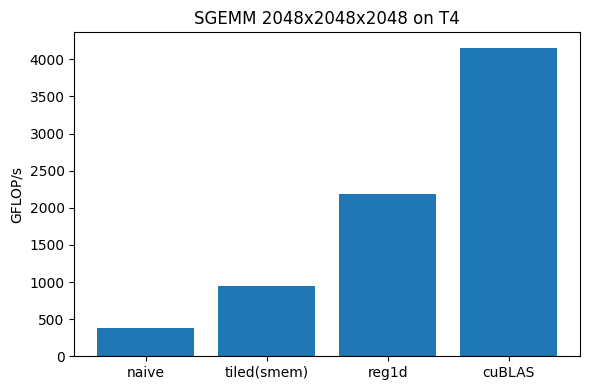

saved gemm_gflops.png


In [14]:
import matplotlib.pyplot as plt
gflops = {
    'naive':       	383.1,
    'tiled(smem)': 940.3,
    'reg1d':       2185.9,
    'cuBLAS':     4155.1,
}
names = list(gflops.keys()); vals = list(gflops.values())
plt.figure(figsize=(6,4))
plt.bar(names, vals)
plt.ylabel('GFLOP/s'); plt.title('SGEMM 2048x2048x2048 on T4')
plt.tight_layout(); plt.savefig('gemm_gflops.png', dpi=150); plt.show()
print('saved gemm_gflops.png')